# Hard - Three years overlaid: the anomaly signal

In the **Medium** notebook we built a clean NDVI curve for one season. Useful, but you can't tell if a season is *good* or *bad* without comparing it to something.

Today we do exactly that.

## What we'll do

1. Loop the Medium pipeline over **three contrasting seasons**: `2021` (great year), `2023` (severe drought), `2025` (recovery).
2. Realign every curve on **day-of-season** (Sept → Aug for winter wheat) so they overlay on the same x-axis.
3. Plot the three curves on top of each other, with a baseline envelope.
4. Compute the **anomaly** of the most recent season vs the historical mean - the actual trading signal.
5. Cross-check against the NASS yield published for each season.

## Why these three years

Sumner County, KS yields (bu/acre): **2021 = 48** (great), **2023 = 26** (drought disaster), **2025 = 46** (back to normal). Three very different stories on the same patch of land. The NDVI curves should make those differences visible **months before** USDA published the yields.

Run time: \~10 minutes (3 × Sentinel-2 fetch). First CDL run: \~10 GB download (3 years × 3 GB), one-time. Cached after.

## 0. Setup

Same dependencies as the Medium notebook. NASS key required (free, 30 seconds at https://quickstats.nass.usda.gov/api).

In [1]:
# %pip install -q pystac-client planetary-computer odc-stac rioxarray requests python-dotenv scipy matplotlib pandas numpy

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pystac_client import Client
import planetary_computer
import odc.stac
import rioxarray
from rasterio.warp import transform_bounds
from rasterio.enums import Resampling
from scipy.ndimage import binary_erosion

load_dotenv()
NASS_API_KEY = os.environ.get("NASS_API_KEY")
if not NASS_API_KEY:
    NASS_API_KEY = input("Paste your NASS QuickStats API key: ").strip()

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print("Setup ready.")

Setup ready.


## 1. Pick the area and the years

Same Sumner County, KS bbox. Three target seasons.

In [2]:
BBOX = [-97.50, 37.20, -97.45, 37.25]
STATE = "KS"
COUNTY = "SUMNER"
WINTER_WHEAT_CLASS = 24

YEARS = [2021, 2023, 2025]

print(f"Area : ~{(BBOX[2]-BBOX[0])*88:.1f} km x {(BBOX[3]-BBOX[1])*111:.1f} km")
print(f"Years: {YEARS}")

Area : ~4.4 km x 5.5 km
Years: [2021, 2023, 2025]


## 2. Refactor the Medium pipeline into reusable functions

The Medium notebook ran the pipeline once. Here we run it three times, so we wrap each step in a small function. This is also exactly what you'd do when productionising - your `cdl_connector` and `sentinel2_connector` would look very similar to these.

Four helpers:

- `fetch_usda_cdl(year)` - download + cache the national CDL TIFF.
- `load_cdl_for_bbox(bbox, year)` - clip the CDL to our bbox.
- `build_wheat_mask_on_s2_grid(cdl_da, s2)` - reproject the mask to the Sentinel-2 grid, with optional erosion.
- `compute_ndvi_season(bbox, year, erode=True)` - full pipeline for one year, returns a clean NDVI time series.

In [3]:
CDL_CACHE = Path("data/bronze/usda_cdl")
CDL_CACHE.mkdir(parents=True, exist_ok=True)


def fetch_usda_cdl(year: int) -> Path:
    """Download the national CDL GeoTIFF for a given year. Cached locally."""
    cached = next(CDL_CACHE.rglob(f"{year}_30m_cdls.tif"), None)
    if cached is not None:
        return cached
    url = f"https://www.nass.usda.gov/Research_and_Science/Cropland/Release/datasets/{year}_30m_cdls.zip"
    zip_path = CDL_CACHE / f"{year}_30m_cdls.zip"
    print(f"  Downloading CDL {year} (~3 GB, one-time)...")
    with requests.get(url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        done = 0
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=16 * 1024 * 1024):
                f.write(chunk); done += len(chunk)
                if total:
                    print(f"\r    {100*done/total:5.1f}%", end="", flush=True)
        print()
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(CDL_CACHE)
    zip_path.unlink()
    return next(CDL_CACHE.rglob(f"{year}_30m_cdls.tif"))


def load_cdl_for_bbox(bbox_lonlat, year):
    tif = fetch_usda_cdl(year)
    cdl = rioxarray.open_rasterio(tif).squeeze()
    bbox_proj = transform_bounds("EPSG:4326", cdl.rio.crs, *bbox_lonlat)
    return cdl.rio.clip_box(*bbox_proj)


def build_wheat_mask_on_s2_grid(cdl_da, s2, erode=True):
    s2_epsg = int(s2["spatial_ref"].values)
    s2_target = s2.isel(time=0).rio.write_crs(f"EPSG:{s2_epsg}")
    wheat_da = ((cdl_da == WINTER_WHEAT_CLASS).astype("uint8")
                .rio.write_crs(cdl_da.rio.crs))
    mask = wheat_da.rio.reproject_match(s2_target, resampling=Resampling.nearest) > 0
    if erode:
        mask = mask.copy(data=binary_erosion(mask.values, iterations=3))
    return mask


def compute_ndvi_season(bbox, year, erode=True):
    """Full pipeline for one season. Returns a DataFrame (date, ndvi)."""
    print(f"Season {year}:")

    # 1. CDL mask
    cdl_da = load_cdl_for_bbox(bbox, year)

    # 2. Sentinel-2 over the season (Sept of previous year -> end of harvest year)
    items = list(catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=f"{year-1}-09-01/{year}-08-31",
        query={"eo:cloud_cover": {"lt": 30}},
    ).items())
    print(f"  {len(items)} S2 scenes found")

    s2 = odc.stac.load(
        items, bands=["B04", "B08", "SCL"], bbox=bbox,
        resolution=10, groupby="solar_day", chunks={},
    )

    # 3. NDVI + cloud mask
    BAD_SCL = [3, 8, 9, 10, 11]
    valid = ~s2["SCL"].isin(BAD_SCL)
    red = s2["B04"].where(valid).astype("float32")
    nir = s2["B08"].where(valid).astype("float32")
    ndvi = (nir - red) / (nir + red + 1e-6)

    # 4. Mask to wheat (eroded core)
    mask = build_wheat_mask_on_s2_grid(cdl_da, s2, erode=erode)
    print(f"  {int(mask.sum())} wheat pixels on S2 grid (eroded={erode})")

    # 5. Aggregate per date
    ts = ndvi.where(mask).mean(dim=["y", "x"]).compute()
    df = pd.DataFrame({
        "date": pd.to_datetime(ts["time"].values),
        "ndvi": ts.values,
    }).dropna().sort_values("date").reset_index(drop=True)
    print(f"  peak NDVI = {df['ndvi'].max():.2f}")
    return df

## 3. Run the pipeline for each season

Three calls. First time: each new year triggers a \~3 GB CDL download. After that, all cached and the loop is fast.

In [4]:
seasons = {y: compute_ndvi_season(BBOX, y) for y in YEARS}

Season 2021:
    100.0%
  44 S2 scenes found
  54164 wheat pixels on S2 grid (eroded=True)


/Users/lucasinglese/Library/Caches/pypoetry/virtualenvs/quantlake-UZuDkhhv-py3.13/lib/python3.13/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


  peak NDVI = 0.82
Season 2023:
    100.0%
  52 S2 scenes found
  79565 wheat pixels on S2 grid (eroded=True)
  peak NDVI = 0.41
Season 2025:
  43 S2 scenes found
  81306 wheat pixels on S2 grid (eroded=True)
  peak NDVI = 0.49


## 4. Align all seasons on the same x-axis

Winter wheat in Kansas is sown in **September** of year N-1 and harvested in **June-July** of year N. So "season 2025" really runs from Sept 1, 2024 to Aug 31, 2025.

We define **day-of-season** as the number of days since Sept 1 of the previous calendar year:

- day 0   = Sept 1
- day 122 = Dec 31
- day 242 = April 30
- day 273 = May 31 (around heading)
- day 303 = June 30 (around harvest)

Once every curve is indexed by day-of-season, we can plot them on the same axis and compare them stage-by-stage.

In [5]:
def add_day_of_season(df, harvest_year):
    start = pd.Timestamp(year=harvest_year - 1, month=9, day=1)
    df = df.copy()
    df["doy_season"] = (df["date"] - start).dt.days
    return df

seasons_aligned = {y: add_day_of_season(df, y) for y, df in seasons.items()}
seasons_aligned[YEARS[0]].head()

,date,ndvi,doy_season
0,2020-09-06 17:08:49.024,0.332145,5
1,2020-09-21 17:10:21.024,0.230760,20
2,2020-09-26 17:09:59.024,0.267570,25
3,2020-10-01 17:11:31.024,0.250193,30
4,2020-10-06 17:11:09.024,0.236346,35


## 5. Plot the three seasons overlaid

Here's the money plot. Each colour is one season. The seasonal pattern is the same template, but the **amplitude** and **timing** of the peak differ - and that's where the alpha is.

Look at:
- The **peak NDVI** - how high does each curve reach in spring?
- The **timing of green-up** - when does the curve climb?
- The **post-peak decline** - how fast does it fall off (early stress → faster fall)?

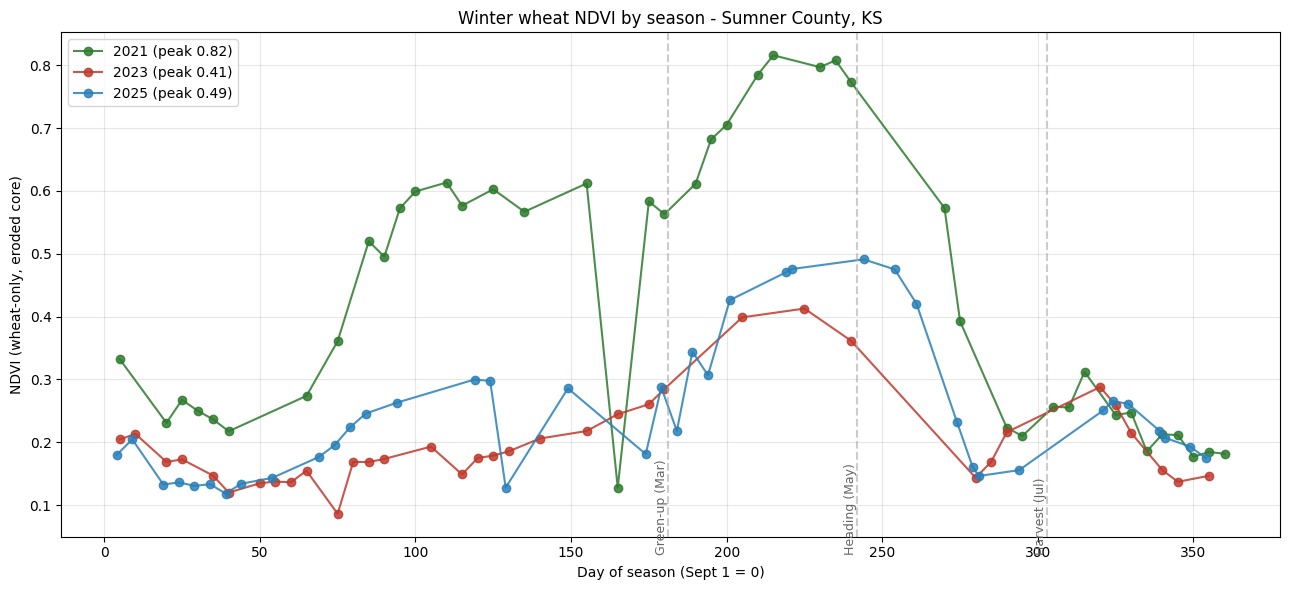

In [6]:
colors = {2021: "#2d7a2d", 2023: "#c0392b", 2025: "#2980b9"}

fig, ax = plt.subplots(figsize=(13, 6))
for year, df in seasons_aligned.items():
    ax.plot(df["doy_season"], df["ndvi"], "o-",
            color=colors.get(year, "#444"), alpha=0.85,
            label=f"{year} (peak {df['ndvi'].max():.2f})")

# Annotate phenology landmarks
for label, doy in [("Green-up (Mar)", 181), ("Heading (May)", 242), ("Harvest (Jul)", 303)]:
    ax.axvline(doy, ls="--", color="#aaa", alpha=0.6)
    ax.text(doy, 0.02, label, rotation=90, ha="right", va="bottom",
            fontsize=9, color="#666")

ax.set_xlabel("Day of season (Sept 1 = 0)")
ax.set_ylabel("NDVI (wheat-only, eroded core)")
ax.set_title(f"Winter wheat NDVI by season - {COUNTY.title()} County, {STATE}")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 6. Build the anomaly

To turn this into a single signal, we pick a **baseline** (here, the average of the older seasons) and compute the most recent season's deviation from it on each day-of-season.

We interpolate everything onto a common day grid so we can do arithmetic. Then `ndvi_2025 - mean(2021, 2023)` is our anomaly curve. Positive = above normal (good year), negative = below normal (stressed).

With more years you'd compute the mean and ±1σ envelope from say 10 historical seasons. With three years the baseline is noisy - but the structure is the same as a 10-year version.

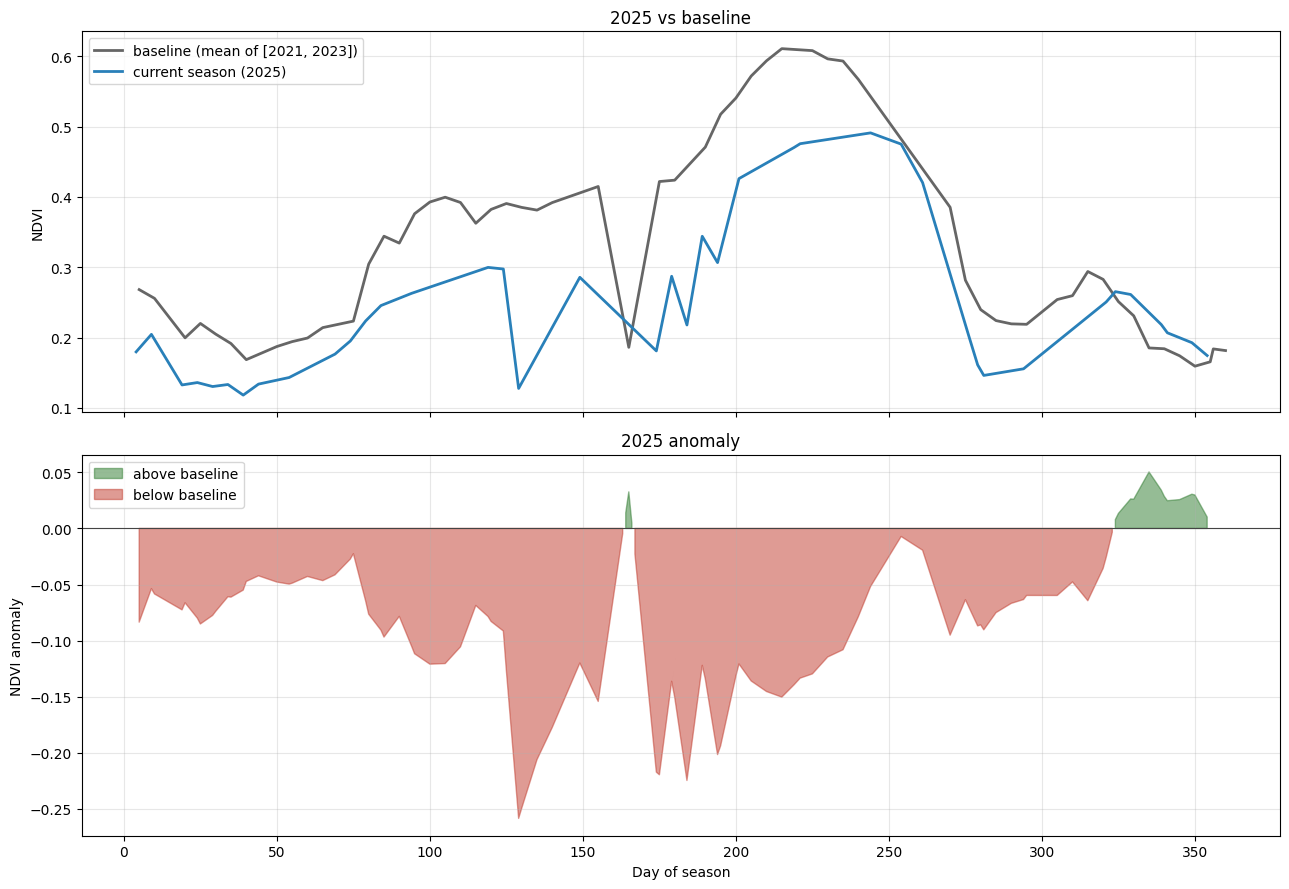

In [7]:
# Common daily grid across the whole season
doy_grid = np.arange(0, 365)

def interp_to_grid(df):
    return np.interp(doy_grid, df["doy_season"], df["ndvi"],
                     left=np.nan, right=np.nan)

baseline_years = [y for y in YEARS if y < max(YEARS)]   # [2021, 2023]
current_year   = max(YEARS)                              # 2025

baseline = np.nanmean(
    np.vstack([interp_to_grid(seasons_aligned[y]) for y in baseline_years]),
    axis=0,
)
current = interp_to_grid(seasons_aligned[current_year])
anomaly = current - baseline

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax1.plot(doy_grid, baseline, color="#666", lw=2,
         label=f"baseline (mean of {baseline_years})")
ax1.plot(doy_grid, current, color="#2980b9", lw=2,
         label=f"current season ({current_year})")
ax1.set_ylabel("NDVI")
ax1.set_title(f"{current_year} vs baseline")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2.fill_between(doy_grid, anomaly, 0,
                 where=anomaly >= 0, color="#2d7a2d", alpha=0.5, label="above baseline")
ax2.fill_between(doy_grid, anomaly, 0,
                 where=anomaly < 0,  color="#c0392b", alpha=0.5, label="below baseline")
ax2.axhline(0, color="#444", lw=0.8)
ax2.set_xlabel("Day of season")
ax2.set_ylabel("NDVI anomaly")
ax2.set_title(f"{current_year} anomaly")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Does the NDVI track the yield?

The whole point. We compute a simple **NDVI feature** for each season - peak NDVI in the green-up window (March-May, day-of-season 180–260) - and pair it with the official NASS yield for that season.

If the satellite signal is real, low NDVI years should align with low yields, and vice versa.

In [8]:
NASS_URL = "https://quickstats.nass.usda.gov/api/api_GET/"

def nass_query(params):
    p = {"key": NASS_API_KEY, "format": "JSON", **params}
    r = requests.get(NASS_URL, params=p, timeout=60)
    r.raise_for_status()
    return pd.DataFrame(r.json()["data"])


yields_raw = nass_query({
    "source_desc": "SURVEY",
    "commodity_desc": "WHEAT",
    "statisticcat_desc": "YIELD",
    "unit_desc": "BU / ACRE",
    "agg_level_desc": "COUNTY",
    "state_alpha": STATE,
    "county_name": COUNTY,
    "year__GE": str(min(YEARS) - 1),
})
yields_raw = yields_raw[yields_raw["short_desc"].str.contains("WINTER", na=False)].copy()
yields_raw["year"] = yields_raw["year"].astype(int)
yields_raw["yield_bu_acre"] = pd.to_numeric(
    yields_raw["Value"].str.replace(",", ""), errors="coerce")
yields_df = yields_raw.dropna(subset=["yield_bu_acre"]).set_index("year")

rows = []
for y, df in seasons_aligned.items():
    spring = df[df["doy_season"].between(180, 260)]
    peak = spring["ndvi"].max() if not spring.empty else np.nan
    rows.append({
        "year": y,
        "peak_ndvi_spring": peak,
        "yield_bu_acre": yields_df["yield_bu_acre"].get(y, np.nan),
    })
summary = pd.DataFrame(rows)
summary

,year,peak_ndvi_spring,yield_bu_acre
0,2021,0.815833,48.0
1,2023,0.412761,26.0
2,2025,0.491054,46.3


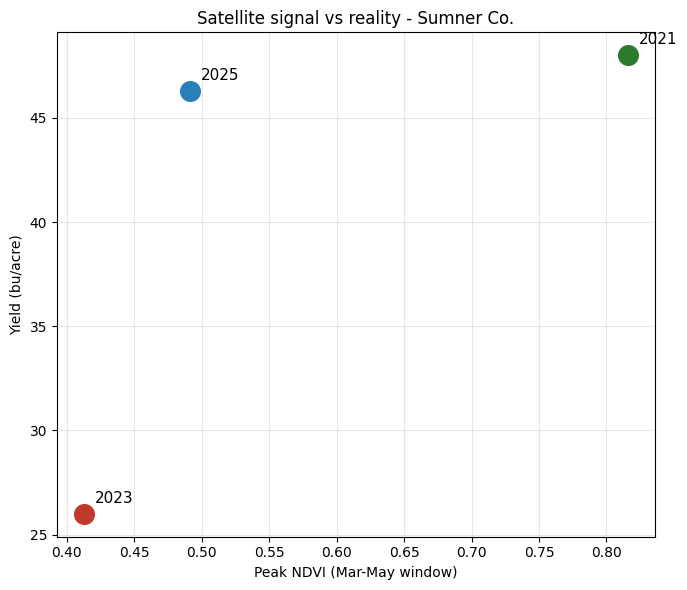

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for _, row in summary.iterrows():
    ax.scatter(row["peak_ndvi_spring"], row["yield_bu_acre"],
               s=200, color=colors.get(row["year"], "#444"))
    ax.annotate(f"{int(row['year'])}",
                (row["peak_ndvi_spring"], row["yield_bu_acre"]),
                xytext=(8, 8), textcoords="offset points", fontsize=11)
ax.set_xlabel("Peak NDVI (Mar-May window)")
ax.set_ylabel("Yield (bu/acre)")
ax.set_title(f"Satellite signal vs reality - {COUNTY.title()} Co.")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. What you just did

You built a working **anomaly detector for US winter wheat yields**, using:

- 100% free public data (USDA + Microsoft Planetary Computer)
- Three sources combined (Sentinel-2 + CDL + NASS)
- Standalone Python code you can run on a laptop or Colab

With three years your baseline is naive. **Run the same loop with 5-10 years and you have a real trading signal** - a curve that, every week during the growing season, tells you whether the current crop is tracking above or below historical norms. That's the kind of input WASDE-forecasting desks pay for.

## Where this goes next (in production)

What we did on a tiny 5 × 5 km bbox scales - the code is identical, only the orchestration changes.

**Step 1 - Scale to a county**. Replace the bbox with Sumner County's full polygon (\~3 000 km²). \~5 GB of S2 to stream per season. Manageable on Colab.

**Step 2 - Scale to the top wheat counties**. \~30-50 counties cover 75% of US winter wheat production. Loop the per-county pipeline. \~3-5 hours of compute on the free [Planetary Computer Hub](https://planetarycomputer.microsoft.com/compute) for one full season.

**Step 3 - Scale to CONUS**. \~3,143 counties. \~24-48 hours on the PC Hub free tier for one season. **Still free.** Once the historical backfill is done, daily incremental updates are trivial (\~10 minutes/day on a laptop).

**Step 4 - Wrap as `quantlake` connectors**. Same medallion pattern (bronze/silver/gold) as the rest of the project:

| Connector | Trigger | Frequency |
|---|---|---|
| `cdl_connector.fetch(year)` | Annual | Jan/Feb when USDA publishes |
| `sentinel2_connector.poll(bbox)` | Cron daily | New scenes over the AOI |
| `nass_connector.poll()` | Cron weekly (Mon evening) | Crop Progress release |

Each connector is \~50 lines, drop-in compatible with the rest of `quantlake`.

## The point

Hedge funds pay teams of engineers to do exactly this. The data is the same. The maths is the same. **The only thing separating the home setup from the pro setup is engineering elbow grease.** And now you have the template.